# FAQ selection

**Recipe 08** · Level 1 (Beginner) · Decision type: `Choice`

Select the best matching FAQ from a short candidate list, including a no-match outcome when none addresses the question.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A small FAQ-selection assistant. Jev reads one customer question and picks exactly one of seven options: six fixed FAQ identifiers (`password_reset`, `change_email`, `cancel_subscription`, `billing_cycle`, `export_data`, `delete_account`) or the explicit fallback `no_match`, which the use case names for a question none of the six addresses. Python owns everything else: the FAQ catalog and its stored answer text, and the rule that returns a confident real match's stored answer, reports `no_match` as a final "no FAQ fits" result whatever its confidence, and sends anything else uncertain to an explicit `review` outcome instead of guessing. By the end you will have looked at individual typed answers across the full range of confidence -- including one that is wrong and one that is held back for review -- seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports top-1 accuracy, the `no_match` outcome's own precision and recall, and a selective accuracy, coverage and risk computed from what the rule actually did -- not from reapplying a threshold `no_match` was never gated by in the first place.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# question that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)["faq"]
    return answered[example.id]


run_header(
    8,
    "FAQ selection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 08: FAQ selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `question_id` and `text`, the customer's question. `build_state` passes on the question text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its question.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-ambiguous"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "question_id": "Q3001",
  "text": "I need to update my account because I don't recognize the email address listed anymore."
}
Jev sees:
{
  "question": "I need to update my account because I don't recognize the email address listed anymore."
}


## The questions

There is one question, and it asks one thing: which FAQ, if any, best answers this customer's question? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order). Six of the seven options are the FAQ identifiers this recipe's catalog names; Python builds the option set and holds the stored answer text for each one, and returns that text unchanged for a confident match -- the model never writes the answer ([S06](https://docs.typesafe.ai/cookbooks) covers this shape, skill and option selection over a fixed candidate set, as a worked pattern). The seventh, `no_match`, is the explicit fallback the use case names for a question that does not resolve to one of the six FAQs. Each option's description says what belongs to it and, for the three pairs that are easiest to confuse -- a password question against an email-on-file question, a cancellation against a billing-date question, and a cancellation against a full account deletion -- what belongs to the other option instead.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): with seven options, 0 when the top option holds no more than a seventh of the probability, 1 when one option holds all of it. It depends only on that top probability, not on how the rest is spread across the other six, so a low confidence here does not mean the question is unreadable; it means the top option did not pull far ahead of an even seventh, which, for a question that could plausibly go to two FAQs, is often the honest shape for the probabilities to take.

[S04](https://docs.typesafe.ai/concepts/how-to-build-with-system-one) frames this kind of decision as one narrow judgment embedded in code that keeps control flow: Jev picks an option, and Python (`select_faq` in `helpers.py`, below) decides what that option is allowed to do -- return the FAQ's stored answer, report `no_match` as a final result, or hold the answer back for review.

In [3]:
faq = questions["faq"]
print(faq.instructions)
for name, description in faq.criteria.items():
    print(f"  {name:24s} {description}")

Which one of these FAQs, if any, best answers the customer's question?
  password_reset           The question asks how to reset a forgotten password or sign back in after being locked out by a wrong password. A request to change the email address on the account instead belongs to change_email.
  change_email             The question asks how to change the email address on the account, for example after switching jobs or email providers. A request to recover a forgotten password instead belongs to password_reset.
  cancel_subscription      The question asks how to cancel a paid subscription so it does not renew again, or asks to stop being charged, with the account itself left open. A question only about when the next charge happens, with no request to stop anything, belongs to billing_cycle instead; a request to remove the account itself, not just stop paying, belongs to delete_account instead.
  billing_cycle            The question asks when the account will next be charged or how o

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a question that could plausibly be `change_email` or `password_reset`, a question none of the six FAQs addresses, and a question whose stored answer is simply wrong -- a real FAQ, confidently enough to matter, but not the one the question is actually asking about. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call. These three come from the `demo` and `validation` splits only; `test` is reported once, after every choice below is frozen, not peeked at here.

Choice: change_email (confidence 0.32)
  change_email         0.42  ########
  password_reset       0.35  #######
  cancel_subscription  0.05  #
  billing_cycle        0.05  #
  export_data          0.05  #
  delete_account       0.05  #
  no_match             0.05  #
Provenance: synthetic


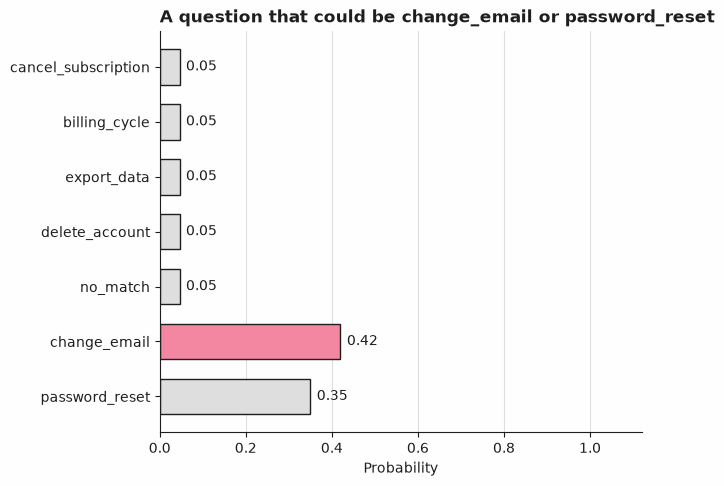

In [4]:
ambiguous_example = demo["d01-ambiguous"]
ambiguous_answer = decide(ambiguous_example)
show_answer(ambiguous_answer)
plot_answer_probabilities(
    ambiguous_answer, title="A question that could be change_email or password_reset"
)

The question is framed around not recognizing the email on the account, which reads most directly as a request to change it, so the stored answer puts `change_email` only just ahead of `password_reset`, 0.42 against 0.35, for a `confidence` of 0.32: `(0.42 - 1/7) / (6/7)`. "Gold label" below means the correct answer written down in `labels.jsonl` before this notebook ever runs, decided in advance from the rule each option's description states, not from the model; this particular row is a `demo` example and carries no gold label at all (no `demo` example in this recipe does), so there is nothing to score it against here -- its purpose is to show the probabilities, not to be marked right or wrong. A reader could reasonably read "I don't recognize the email anymore" as a sign of compromised access instead of a request to update it, which is exactly why the probabilities are this close rather than confidently one-sided.

In [5]:
no_match_example = demo["d02-no-match"]
no_match_answer = decide(no_match_example)
show_answer(no_match_answer)

Choice: no_match (confidence 0.51)
  no_match             0.58  ############
  billing_cycle        0.15  ###
  password_reset       0.05  #
  change_email         0.05  #
  cancel_subscription  0.05  #
  export_data          0.05  #
  delete_account       0.05  #
Provenance: synthetic


Paying by cryptocurrency is not something any of the six FAQs covers, and the probabilities show it: `no_match` leads clearly at 0.58, with `billing_cycle` the only real runner-up at 0.15, because the question is at least about payment. `no_match`'s `confidence`, 0.51, matters for how this answer reads but not for what Python does with it: `select_faq`, below, reports `no_match` as a final result whatever its confidence, because the option itself already says no FAQ fits -- there is no stored FAQ answer a confidence check could protect here.

In [6]:
wrong_example = next(e for e in examples if e.id == "v06-ambiguous-wrong")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["text"])
show_answer(wrong_answer)

I want this to end before my card gets charged again.
Choice: billing_cycle (confidence 0.33)
  billing_cycle        0.43  #########
  cancel_subscription  0.30  ######
  password_reset       0.05  #
  change_email         0.05  #
  export_data          0.05  #
  delete_account       0.05  #
  no_match             0.05  #
Provenance: synthetic


The gold label here (written down in `labels.jsonl`, not produced by Jev) is `cancel_subscription` -- "I want this to end" is an explicit request to stop the subscription, not a question about when the next charge happens. The stored answer gets this wrong: `billing_cycle` at 0.43 against `cancel_subscription`'s 0.30, a `confidence` of 0.33. This is the one wrong answer this recipe places in `validation` itself, on purpose: without it, every real-FAQ answer in `validation` would be correct, and the threshold chosen two cells below would have nothing to cut on (it would come back as whatever the lowest observed confidence happens to be, whatever accuracy target is asked for). With it, the threshold has a real wrong answer to exclude, and -- as the next section shows -- it does exclude this one.

## Python's part

Jev supplies the judgment; what happens with it is code. `select_faq` in `helpers.py` returns the stored FAQ answer for a confident real match, reports `no_match` as a final, un-gated result whatever its confidence (the options are FAQ identifiers from a short candidate list plus `no_match`, and Python returns the stored FAQ answer by identifier, never a model-written one -- `no_match` has no stored answer a confidence check could protect), and sends anything else below the threshold to an explicit `review` outcome instead of returning a possibly wrong FAQ. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for a confident and a low-confidence answer of every one of the six real FAQs, and for `no_match` at both a high and a low confidence, so a rule that quietly exempted one FAQ from the threshold, or started gating `no_match` on confidence after all, would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate, over the `validation` questions whose stored answer names a real FAQ (the ones whose stored answer names `no_match` are excluded from this selection on purpose -- `select_faq` never applies the threshold to them, so feeding their confidence into the same selection would tune a gate the rule does not have). `v06-ambiguous-wrong` above is the one wrong answer in that pool; the frozen threshold is the lowest cut that excludes it -- but that cut is not free. `v18-ambiguous`, a *correct* `billing_cycle` answer at confidence 0.3000, sits below the same cut and is reviewed along with it, as the next section's `review: 2` count shows: excluding one wrong, confident answer also means giving up one correct, cautious one, because confidence alone cannot tell the two apart. Applying that frozen threshold to the three answers shown above, plus one clearly `password_reset` question for contrast, shows all three outcomes the rule can produce -- including, for the first time, a question that is sent to `review` -- and what Python returns for each: the stored FAQ text for a confident match, and `None` for `no_match` and `review` alike, since neither of those hands back a stored answer.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only the questions whose stored answer names a real FAQ go into the threshold selection: a
# `no_match` answer is never gated on confidence, so its confidence has no business tuning the
# gate.
real_match = [
    (a.choice == g, a.confidence)
    for a, g in zip(val_answers, val_gold, strict=True)
    if a.choice != helpers.NO_MATCH
]
real_correct = [correct for correct, _ in real_match]
real_confidence = [conf for _, conf in real_match]
threshold = select_confidence_threshold(real_correct, real_confidence, target_accuracy=1.0)
print(
    f"chosen threshold, frozen from here on: {threshold:.4f} "
    f"(over {len(real_match)} real-FAQ matches in validation, 1 of them wrong){selection}{check}"
)

confident_example = next(e for e in val_examples if e.id == "v01-password-reset")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (ambiguous_example, ambiguous_answer),
    (no_match_example, no_match_answer),
    (wrong_example, wrong_answer),
    (confident_example, confident_answer),
):
    result = helpers.select_faq(shown_example.fields["question_id"], shown_answer, threshold)
    print(
        f"{result.question_id}: {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )
    print(f"  answer returned to the customer: {result.answer!r}")

chosen threshold, frozen from here on: 0.3467 (over 14 real-FAQ matches in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
Q3001: change_email at confidence 0.32 -> review (confidence below the threshold)
  answer returned to the customer: None
Q3002: no_match at confidence 0.51 -> no_match (no FAQ addresses the question)
  answer returned to the customer: None
Q1006: billing_cycle at confidence 0.33 -> review (confidence below the threshold)
  answer returned to the customer: None
Q1001: password_reset at confidence 0.86 -> matched (confident match)
  answer returned to the customer: "Open the sign-in page, select 'Forgot password', and follow the link we email you to set a new one. The link expires after 30 minutes."


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.select_faq` is applied to every example in `validation` and in `test`, and the outcome counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports **top-1 accuracy**: the fraction of questions where Jev's single most probable option -- its raw `choice`, before `select_faq` does anything with it -- equals the gold label. A confusion matrix shows that same raw choice against the gold labels for every option, and `no_match`'s own precision and recall treat it like any other option: **precision** is the fraction of the rule's `no_match` calls that were actually right, and **recall** is the fraction of the truly-no-match questions the rule actually caught. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, threshold):
    """Apply select_faq to every answer and tally what it actually did."""
    results = [
        helpers.select_faq(e.fields["question_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    counts = {helpers.MATCHED: 0, helpers.REVIEW: 0, helpers.NO_MATCH_OUTCOME: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_answers, threshold)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"top-1 accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"matched: {val_counts[helpers.MATCHED]}, review: {val_counts[helpers.REVIEW]}, "
    f"no_match: {val_counts[helpers.NO_MATCH_OUTCOME]} (of {len(val_examples)}){selection}"
)
val_reviewed = [r for r in val_results if r.outcome == helpers.REVIEW]
print(f"reviewed in validation, listed individually{selection}:")
for r in val_reviewed:
    print(f"  {r.question_id}: {r.label} at the gate, sent to review ({r.reason})")

validation, 19 examples (a selection step, not a reported result)
top-1 accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
matched: 12, review: 2, no_match: 5 (of 19) (a selection step, not a reported result)
reviewed in validation, listed individually (a selection step, not a reported result):
  Q1006: billing_cycle at the gate, sent to review (confidence below the threshold)
  Q1018: billing_cycle at the gate, sent to review (confidence below the threshold)


Two `validation` questions are reviewed: `Q1006` (`v06-ambiguous-wrong` above -- wrong, and this is exactly the error the threshold was chosen to exclude) and `Q1018` (`v18-ambiguous`, a *correct* `billing_cycle` call at confidence 0.30, held back only because its confidence sits below the frozen threshold of 0.3467). That second one is the coverage cost of excluding the first: the threshold cannot tell a cautious correct answer from a confident wrong one by looking at confidence alone, so protecting against `v06-ambiguous-wrong` also means giving up a question `select_faq` would otherwise have answered correctly.

test, 19 examples, threshold 0.3467 frozen (a pipeline check, not a Jev result)
top-1 accuracy of the choice: 0.8421 (a pipeline check, not a Jev result)
matched: 12, review: 2, no_match: 5 (of 19) (a pipeline check, not a Jev result)
Test confusion matrix, gold rows by predicted columns (a pipeline check, not a Jev result):
  predicted ->                   password_reset         change_email  cancel_subscription        billing_cycle          export_data       delete_account             no_match (a pipeline check, not a Jev result)
  gold password_reset                         3                    0                    0                    0                    0                    0                    0 (a pipeline check, not a Jev result)
  gold change_email                           0                    2                    0                    0                    0                    0                    0 (a pipeline check, not a Jev result)
  gold cancel_subscription              

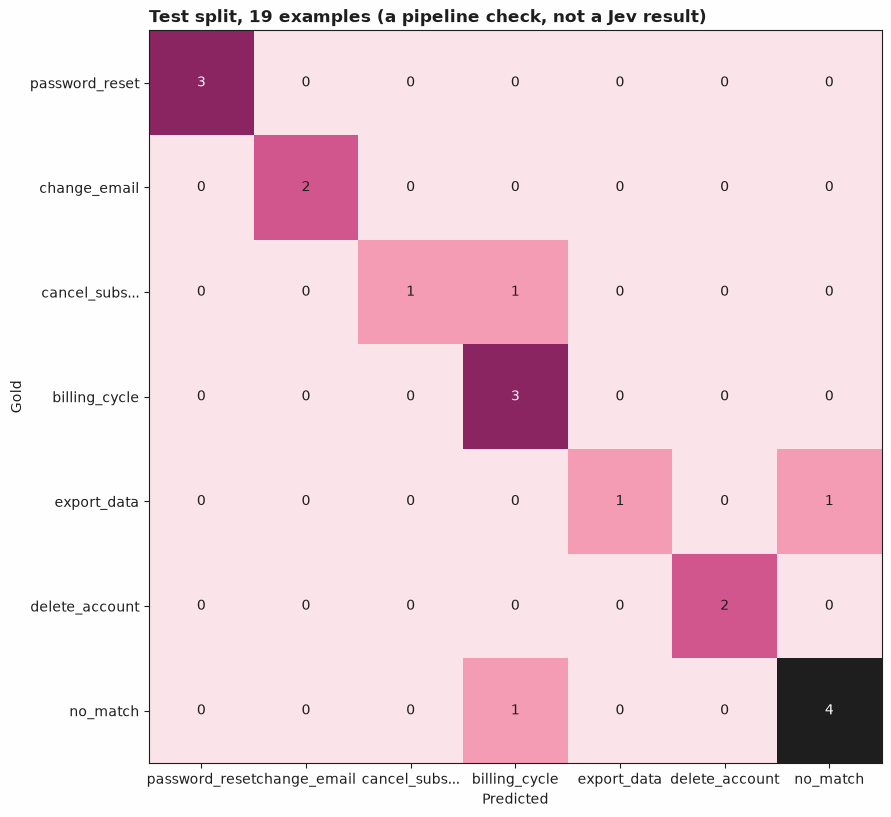

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_counts = report(test_examples, test_answers, threshold)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"top-1 accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"matched: {test_counts[helpers.MATCHED]}, review: {test_counts[helpers.REVIEW]}, "
    f"no_match: {test_counts[helpers.NO_MATCH_OUTCOME]} (of {len(test_examples)}){check}"
)

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
width = max(len(label) for label in matrix.labels)
# The header's leader ("predicted ->") and each row's leader ("gold <label>") are
# different fixed phrases; padding both to the same leader_width, derived from this
# same width, is what keeps the header's columns and every row's columns lined up,
# whatever width this recipe's own labels turn out to need.
leader_width = max(width + len("gold "), len("predicted ->"))
header = "  ".join(f"{label:>{width}s}" for label in matrix.labels)
print(f"Test confusion matrix, gold rows by predicted columns{check}:")
print(f"  {'predicted ->':<{leader_width}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{width}d}" for count in row)
    leader = f"gold {gold_label:<{width}s}"
    print(f"  {leader:<{leader_width}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Three of `test`'s nineteen questions are wrong, in three different ways. "I want to know how to stop being charged every single month" (`t07-ambiguous`) is gold `cancel_subscription` (an explicit request to stop paying), but the stored answer names `billing_cycle` instead at a confidence of 0.5333, comfortably above the frozen threshold (0.3467) -- a real, wrong FAQ the confidence gate lets straight through, because the gate only protects against *low* confidence, not against being confidently wrong. "Can I get a full archive of everything tied to my profile before I leave?" (`t12-no-match-wrong`) is gold `export_data`, but the stored answer names `no_match` -- wrong, and not caught by anything, because `select_faq` never runs `no_match` past the confidence gate at all: the mistake here is not a threshold failing to catch a wrong answer, it is a wrong answer in a branch that has no threshold to fail. "Will my free trial convert to a paid plan automatically?" (`t19-no-match-wrong`) is gold `no_match`, and the stored answer names `billing_cycle` instead, but only at a confidence of 0.2183, below the threshold, so this one *is* caught, and sent to `review` rather than reported. That spread -- one wrong answer the threshold catches, one it does not, and one the threshold was never asked about -- is the point of the outcome summary two cells down.

In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:24s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )
no_match_metrics = per_class["no_match"]
print()
print(
    f"no_match precision {no_match_metrics.precision:.4f}, recall {no_match_metrics.recall:.4f}"
    f"{check}"
)

password_reset           precision 1.000  recall 1.000  f1 1.000  support 3 (a pipeline check, not a Jev result)
change_email             precision 1.000  recall 1.000  f1 1.000  support 2 (a pipeline check, not a Jev result)
cancel_subscription      precision 1.000  recall 0.500  f1 0.667  support 2 (a pipeline check, not a Jev result)
billing_cycle            precision 0.600  recall 1.000  f1 0.750  support 3 (a pipeline check, not a Jev result)
export_data              precision 1.000  recall 0.500  f1 0.667  support 2 (a pipeline check, not a Jev result)
delete_account           precision 1.000  recall 1.000  f1 1.000  support 2 (a pipeline check, not a Jev result)
no_match                 precision 0.800  recall 0.800  f1 0.800  support 5 (a pipeline check, not a Jev result)

no_match precision 0.8000, recall 0.8000 (a pipeline check, not a Jev result)


`f1` is the harmonic mean of precision and recall for that option: a single number that is low whenever either one is, rather than a plain average that a very high precision could paper over a very low recall with. `support` is how many `test` questions actually carry that gold label, so a recall figure is only as meaningful as its support is large -- `cancel_subscription` and `export_data` both have `support` 2 here, so their 0.500 recall is one question each, not a stable rate.

`no_match`'s precision (0.800) is 4 of the 5 questions the rule called `no_match` that truly had no matching FAQ: the fifth is `t12-no-match-wrong` above, a real `export_data` question the rule misreads as having no match at all. Its recall (0.800) is 4 of the 5 `test` questions truly addressed by no FAQ: the fifth is `t19-no-match-wrong` above, which the rule reads as `billing_cycle` instead -- at low confidence, so it is reviewed rather than reported, but it still costs `no_match` its recall on this one question, independently of what happens to it afterwards.

The `matched`/`review`/`no_match` counts above come straight from `select_faq`. `jev_cookbook.evaluation.evaluate_selective` reapplies one confidence threshold to every example, but `select_faq` never applies the threshold to a `no_match` answer, so reapplying it there would score a gate the rule does not have: a rule with a review branch beyond the confidence gate needs its selective numbers computed from the rule's own outcomes, not from a generic helper that assumes the gate is the only branch. `jev_cookbook.evaluation.evaluate_outcomes`, below, does that: it takes what `select_faq` actually decided (`accepted`, built from each result's own `outcome`) and whether that decision was right, never a reconstruction of the rule from a confidence check. Two terms it reports: **coverage** is the fraction of questions the rule actually answered -- `matched` or `no_match`, either one a real result handed back -- rather than held for `review`; among those answered, **accuracy** is the fraction that are right, and **risk** is its complement, `1 - accuracy`, the fraction of answered questions that are wrong despite the rule having delivered a result for them.

The cell below also prints what `evaluate_selective` would report on `test` if the frozen threshold were reapplied to every answer, `no_match` included, purely for contrast. Every stored `no_match` answer in this fixture set happens to sit above that threshold (the lowest is 0.4167, against 0.3467), so the confidence-only view ends up answering exactly the same questions `select_faq` already did, and the two numbers below agree. That is a property of this particular fixture set, not a guarantee `select_faq`'s un-gated `no_match` branch gives in general: a stored `no_match` answer below the threshold would still count as answered under `select_faq` (the branch is never gated on confidence) but as reviewed under `evaluate_selective`, and the two would then diverge.

In [11]:
val_gold_by_id = {e.fields["question_id"]: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted = [r.outcome != helpers.REVIEW for r in val_results]
val_correct = [r.label == val_gold_by_id[r.question_id] for r in val_results]
val_outcomes = evaluate_outcomes(val_accepted, val_correct)
print(
    f"validation: answered {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")

test_gold_by_id = {
    e.fields["question_id"]: g for e, g in zip(test_examples, test_gold, strict=True)
}
test_accepted = [r.outcome != helpers.REVIEW for r in test_results]
test_correct = [r.label == test_gold_by_id[r.question_id] for r in test_results]
test_outcomes = evaluate_outcomes(test_accepted, test_correct)
print()
print(
    f"test: answered {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")

# The confidence-only view, for contrast: evaluate_selective reapplies the frozen threshold to
# every answer, no_match included, with no notion of select_faq's un-gated no_match branch.
test_correct_by_confidence = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
selective = evaluate_selective(test_correct_by_confidence, test_confidence, threshold)
print()
print(
    f"test, confidence-only view: answered {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

validation: answered 17 of 19 (coverage 0.8947) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test: answered 17 of 19 (coverage 0.8947) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8824 (a pipeline check, not a Jev result)
risk among those answered: 0.1176 (a pipeline check, not a Jev result)

test, confidence-only view: answered 17 of 19 (coverage 0.8947) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8824 (a pipeline check, not a Jev result)
risk among those answered: 0.1176 (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the only wrong answer in `validation`, `v06-ambiguous-wrong`, is reviewed rather than answered, so nothing wrong is ever reported there -- that is what choosing the threshold on `validation` is supposed to buy, and it does, on this split. `test`'s risk is not zero, at 0.1176: 15 of the 17 answered questions are right. The two wrong, answered questions are `t07-ambiguous` (a confident wrong FAQ the gate let through) and `t12-no-match-wrong` (a confident wrong `no_match` the gate was never asked about); `t19-no-match-wrong`, the third error, is not among them, because it was reviewed rather than answered. A threshold chosen to be perfectly accurate on `validation` says nothing about any question this recipe has not seen, which is exactly what `test`'s non-zero risk shows. The confidence-only view printed just above reports the same 0.1176: as the cell explains, every `no_match` answer here clears the threshold anyway, so reapplying it everywhere lands on the same split `select_faq` already produced.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored questions (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, four of them wrong on purpose and in different ways (one in `validation` itself, caught by the gate it goes on to define; one in `test` that is wrong and confident through the gate; one in `test` that is wrong and confident through the un-gated `no_match` branch; one in `test` that is wrong but caught by the gate), so every number above describes this fixture set and not a model.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard question to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `select_faq` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how coverage and the review count trade off: loosening it enough to tolerate `v06-ambiguous-wrong` drops the frozen threshold back to 0.3000 and changes which `validation` questions are reviewed.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/), [`04-support-ticket-routing`](../04-support-ticket-routing/), which has its own un-gated `unclear` outcome, and [`09-file-organization`](../09-file-organization/), whose `unsorted` option also bypasses the confidence gate but goes to review rather than being delivered as an answer -- all three build on a `Choice` over a fixed option set like this one; [`03-response-clarity-scoring`](../03-response-clarity-scoring/) for a `Score` question instead.